In [1]:
import tensorflow as tf
from glacierml import data_loader_3

2022-06-21 12:27:55.554372: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df5 = data_loader_3()

importing Glam_2 data


/home/bradlipovsky/anaconda3/envs/comcat/lib/python3.7/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/home/bradlipovsky/notebooks/glac/glacierml.py:248: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['thickness'] = pd.to_numeric(df5['thickness'])


In [4]:
df5

,CenLon,CenLat,Area,thickness,Zmin,Zmed,Zmax,Slope,Aspect,Lmax
0,18.564000,67.915000,1.438,72.0,1204.0,1526.0,1698.0,16.9,98.0,1941.0
1,18.496000,67.910000,3.696,84.0,1207.0,1443.0,2070.0,15.9,282.0,3954.0
2,18.569000,67.903000,3.405,99.0,1143.0,1414.0,1797.0,13.2,102.0,3636.0
3,-121.057350,48.356980,2.924,99.0,1613.0,1891.0,2196.0,12.8,350.0,3338.0
4,-117.284000,52.175400,16.154,150.0,1982.0,2870.0,3448.0,12.6,93.0,10396.0
...,...,...,...,...,...,...,...,...,...,...
326,14.956900,78.013700,2.326,82.0,332.0,482.0,894.0,12.0,338.0,2940.0
327,14.964800,77.953100,2.884,43.0,290.0,498.0,803.0,15.4,4.0,3367.0
328,77.080587,43.043653,2.838,30.0,3427.0,3764.0,4185.0,19.1,359.0,3131.0
329,14.141200,77.944500,5.943,26.0,234.0,338.0,663.0,11.9,69.0,2642.0


In [10]:
import geopandas as gpd

gdf5 = gpd.GeoDataFrame(
    df5, geometry=gpd.points_from_xy(df5.CenLon, df5.CenLat))

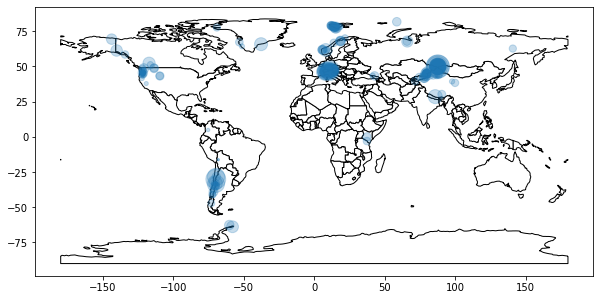

In [27]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(10,10))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

world.plot(color='white', edgecolor='black', ax=ax)

# We can now plot our ``GeoDataFrame``.
gdf5.plot(ax=ax, markersize=gdf5.thickness, alpha=0.25)

plt.show()